# Generative Adversarial Networks #

In [12]:
import tensorflow as tf


#setando uma seed
tf.random.set_seed(1)

#verificando se a gpu está disponível
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [13]:
from tensorflow.keras.datasets import fashion_mnist

#carregando o dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [14]:
import numpy as np

#misturando treino e teste em um só dataset
dataset = np.concatenate([x_train, x_test], axis=0)
#normalizando as imagens
dataset = np.expand_dims(dataset, -1).astype("float32") / 255

In [15]:
BATCH_SIZE = 64

#aplicando o reshape
dataset = np.reshape(dataset, (-1, 28, 28, 1))
#criando um objeto tensorflow dataset
dataset = tf.data.Dataset.from_tensor_slices(dataset)
#configuradno o batch size
dataset = dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE)

In [16]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import LeakyReLU

#escolhendo uma quantidade de random noise
NOISE_DIM = 150

#criando o modelo do gerador
generator = keras.models.Sequential([
  keras.layers.InputLayer(input_shape=(NOISE_DIM,)),  #noise vector
  layers.Dense(7*7*256),
  layers.Reshape(target_shape=(7, 7, 256)),
  layers.Conv2DTranspose(256, 3, strides=2, padding="same"),
  layers.LeakyReLU(alpha=0.2),
  layers.Conv2DTranspose(128, 3, strides=2, padding="same"),
  layers.LeakyReLU(alpha=0.2),
  layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")
])

generator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 12544)          │     1,894,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 14, 14, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 28, 28, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 28, 28, 1)      │         1,153 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,780,417 (10.61 MB)

 Trainable params: 2,780,417 (10.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
#criando o modelo do discriminador

discriminator = keras.models.Sequential([
  keras.layers.InputLayer(input_shape=(28, 28, 1)),
  layers.Conv2D(256, 3, activation="relu", strides=2, padding="same"),
  layers.Conv2D(128, 3, activation="relu", strides=2, padding="same"),
  layers.Flatten(),
  layers.Dense(64, activation="relu"),
  layers.Dropout(0.2),
  layers.Dense(1, activation="sigmoid")
])

discriminator.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 256)    │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 699,137 (2.67 MB)

 Trainable params: 699,137 (2.67 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
#configurando os otimizadores para o gerador e discriminador
optimizerG = keras.optimizers.Adam(learning_rate=0.00001, beta_1=0.5)
optimizerD = keras.optimizers.Adam(learning_rate=0.00003, beta_1=0.5)

#classificador binário
lossFn = keras.losses.BinaryCrossentropy(from_logits=True)

#acurácia
gAccMetric = tf.keras.metrics.BinaryAccuracy()
dAccMetric = tf.keras.metrics.BinaryAccuracy()

In [19]:
@tf.function

#função de treino para o discriminador
def trainDStep(data):
  batchSize = tf.shape(data)[0]
  
  #gerando um lote de noise tensors
  noise = tf.random.normal(shape=(batchSize, NOISE_DIM))

  #concatenando labels verdadeiras e falsas
  y_true = tf.concat(
    [
      #os dados reais são rotulados com 1
      tf.ones(batchSize, 1),
      #os falsos com 0
      tf.zeros(batchSize, 1)
    ],
    axis=0
  )

  with tf.GradientTape() as tape:
    #gerando os dados falsos
    fake = generator(noise)
    #concatenando os dados reais e gerados
    x = tf.concat([data, fake], axis=0)
    #testando se o discriminador consegue julgá-los
    y_pred = discriminator(x)
    #calculando a loss
    discriminatorLoss = lossFn(y_true, y_pred)

  #backpropagation
  grads = tape.gradient(discriminatorLoss, discriminator.trainable_weights)
  optimizerD.apply_gradients(zip(grads, discriminator.trainable_weights))

  #acurácia
  dAccMetric.update_state(y_true, y_pred)

  #retornando a loss
  return {
      "discriminator_loss": discriminatorLoss,
      "discriminator_accuracy": dAccMetric.result()
  }

In [20]:
@tf.function
#função de treino para o gerador
def trainGStep(data):
  batchSize = tf.shape(data)[0]
  noise = tf.random.normal(shape=(batchSize, NOISE_DIM))
 
  y_true = tf.ones(batchSize, 1)

  with tf.GradientTape() as tape:
    #enviando as imagens geradas para o discriminador julgar
    y_pred = discriminator(generator(noise))
    #calculando a loss
    generatorLoss = lossFn(y_true, y_pred)

  #backpropagation
  grads = tape.gradient(generatorLoss, generator.trainable_weights)
  optimizerG.apply_gradients(zip(grads, generator.trainable_weights))

  gAccMetric.update_state(y_true, y_pred)

  return {
      "generator_loss": generatorLoss,
      "generator_accuracy": gAccMetric.result()
  }

In [21]:
from matplotlib import pyplot as plt

#visualizando 81 imagens dado um modelo

def plotImages(model):
    images = model(np.random.normal(size=(81, NOISE_DIM)))

    plt.figure(figsize=(9, 9))

    for i, image in enumerate(images):
        plt.subplot(9,9,i+1)
        plt.imshow(np.squeeze(image, -1), cmap="Greys_r")
        plt.axis('off')

    plt.show();

/home/lucasarenhardt/.local/lib/python3.10/site-packages/keras/src/backend/tensorflow/nn.py:681: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
2024-09-07 16:20:38.706341: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
W0000 00:00:1725736838.757900  119598 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1725736838.778869  119598 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1725736838.781144  119598 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1725736838.784409  119598 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1725736838.787049  119598 gpu_timer.cc:114] Skipping the delay kernel, mea

E:0, Loss G:2.9682, Loss D:0.1191, Acc G:%0.24, Acc D:%98.32


W0000 00:00:1725736876.183081  108352 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1725736876.189871  108352 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1725736876.207791  108352 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1725736876.211452  108352 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1725736876.214485  108352 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1725736876.218001  108352 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1725736876.221346  108352 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1725736876.225305  108352 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1725736876.229900  108352 gp

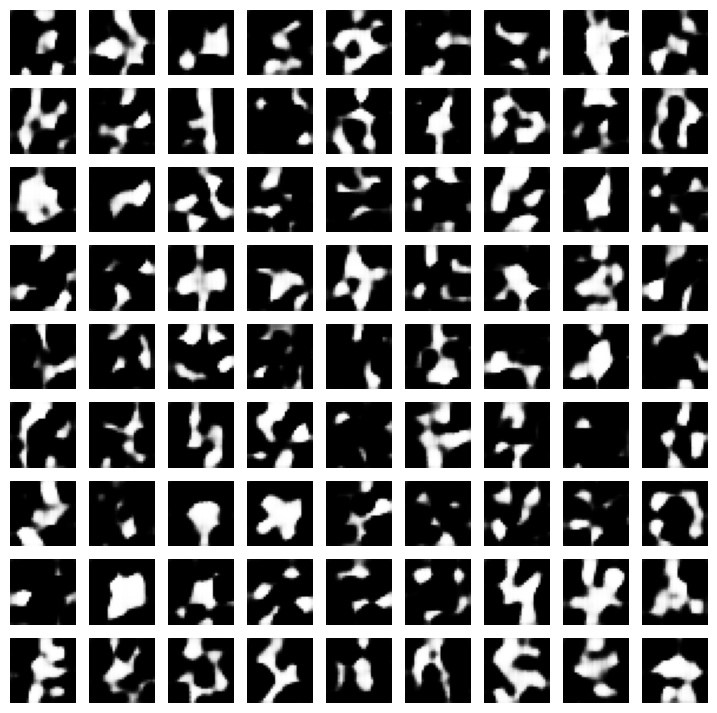

2024-09-07 16:21:50.073969: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


E:1, Loss G:2.9649, Loss D:0.1218, Acc G:%0.72, Acc D:%97.68
E:2, Loss G:3.5810, Loss D:0.0849, Acc G:%0.86, Acc D:%97.52


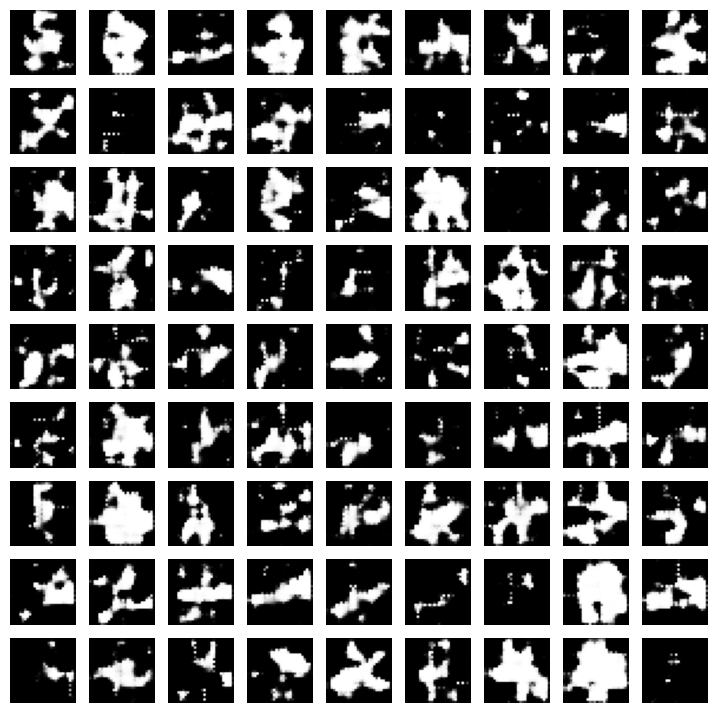

2024-09-07 16:22:57.340409: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


E:3, Loss G:3.3718, Loss D:0.1246, Acc G:%0.96, Acc D:%97.47
E:4, Loss G:2.3434, Loss D:0.2564, Acc G:%1.52, Acc D:%96.61


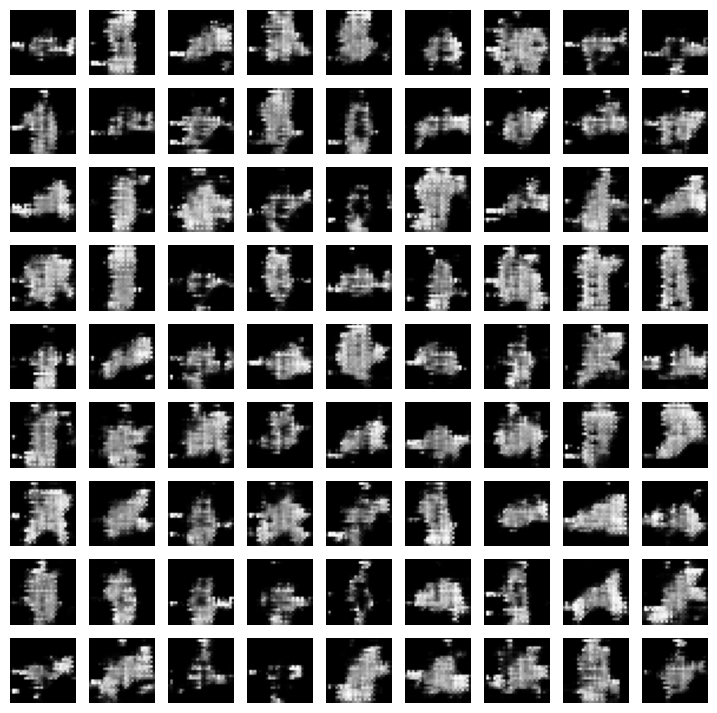

E:5, Loss G:1.8507, Loss D:0.3378, Acc G:%2.41, Acc D:%95.10
E:6, Loss G:1.7785, Loss D:0.3324, Acc G:%3.18, Acc D:%93.80


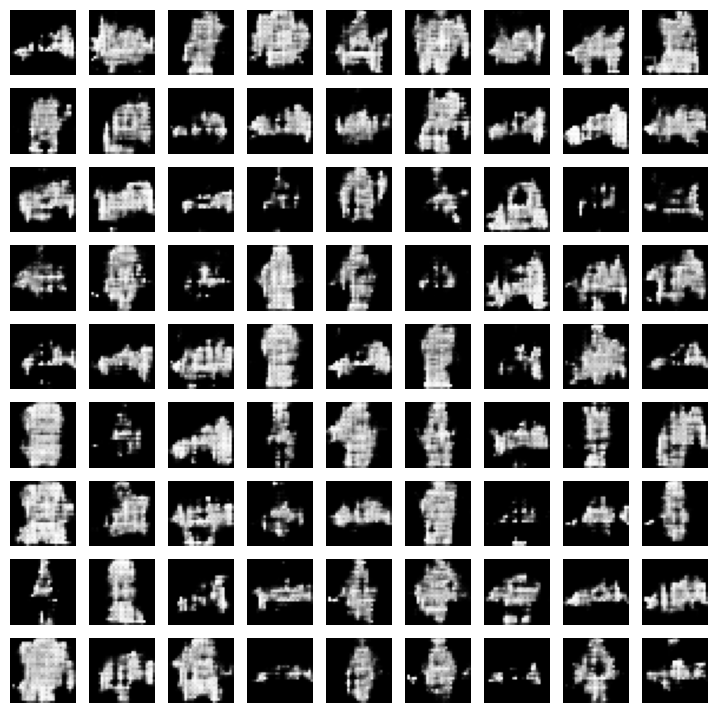

2024-09-07 16:25:12.062006: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


E:7, Loss G:1.7217, Loss D:0.3428, Acc G:%3.80, Acc D:%92.93
E:8, Loss G:1.6334, Loss D:0.3646, Acc G:%4.43, Acc D:%92.16


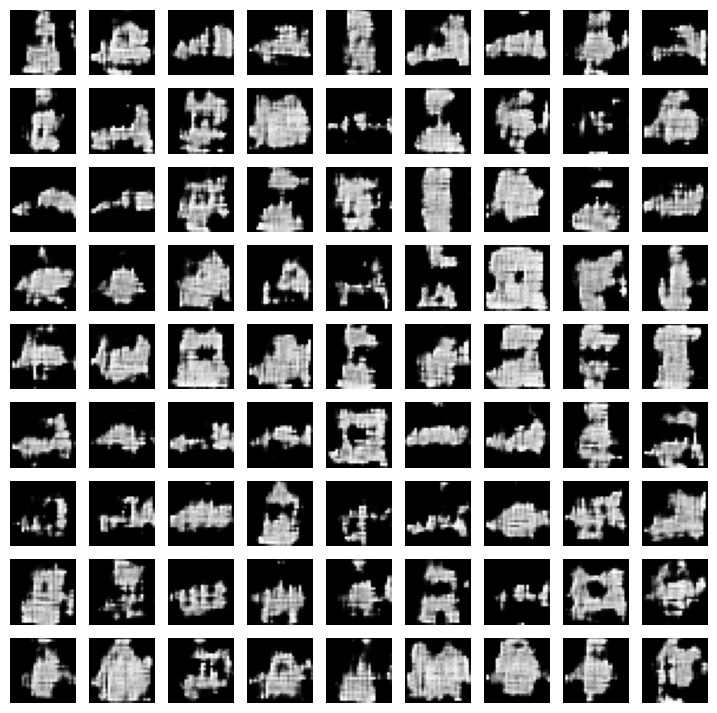

E:9, Loss G:1.6316, Loss D:0.3729, Acc G:%5.09, Acc D:%91.43
E:10, Loss G:1.6101, Loss D:0.3770, Acc G:%5.72, Acc D:%90.78


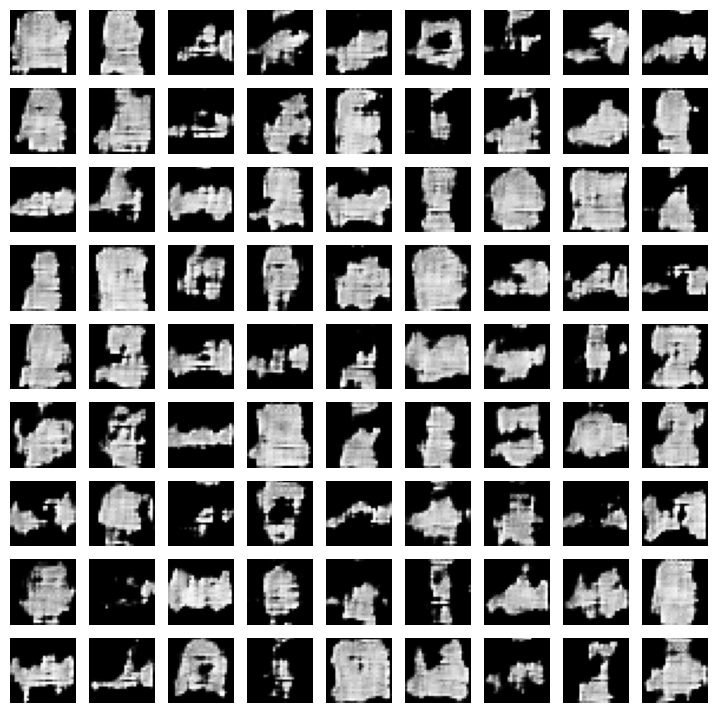

E:11, Loss G:1.6678, Loss D:0.3518, Acc G:%6.15, Acc D:%90.35
E:12, Loss G:1.7321, Loss D:0.3368, Acc G:%6.40, Acc D:%90.07


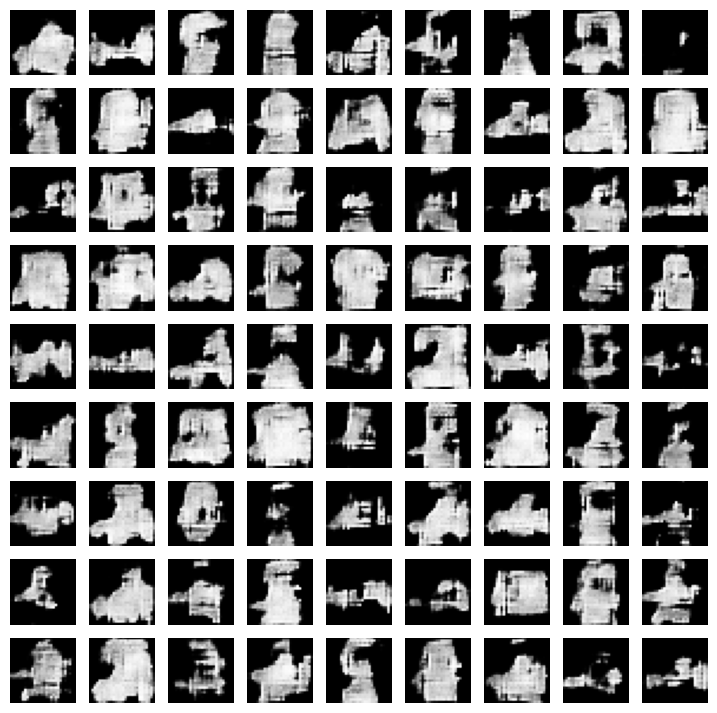

E:13, Loss G:1.7029, Loss D:0.3525, Acc G:%6.60, Acc D:%89.83
E:14, Loss G:1.7205, Loss D:0.3514, Acc G:%6.81, Acc D:%89.59


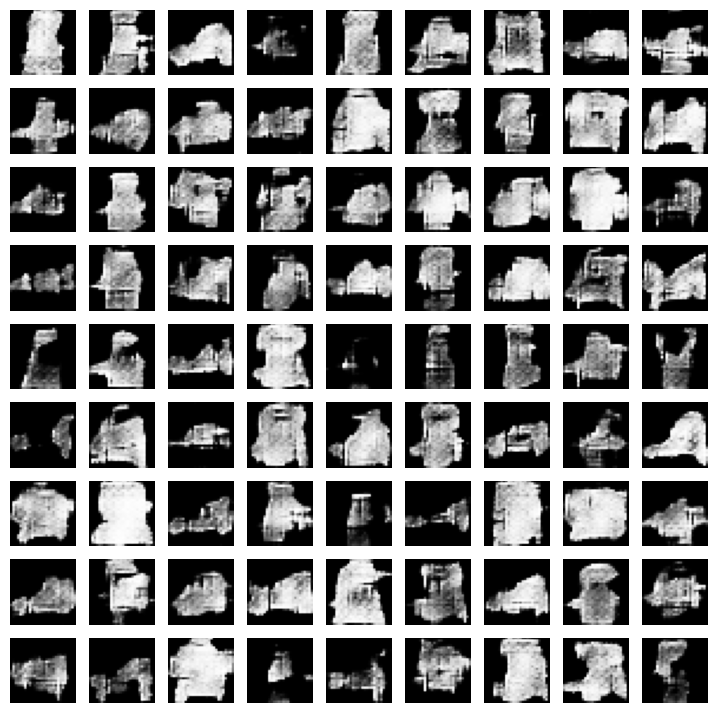

2024-09-07 16:29:42.164850: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


E:15, Loss G:1.7409, Loss D:0.3525, Acc G:%7.02, Acc D:%89.36
E:16, Loss G:1.7407, Loss D:0.3554, Acc G:%7.21, Acc D:%89.15


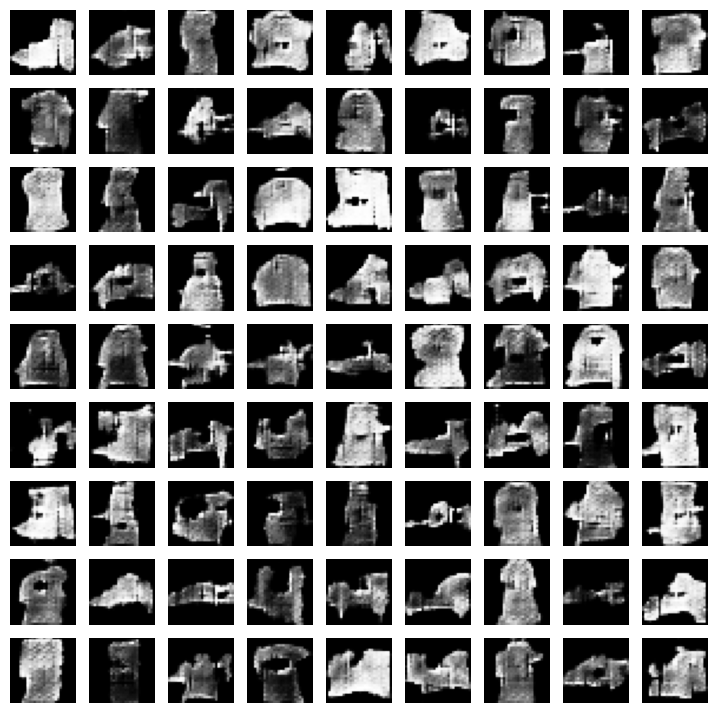

E:17, Loss G:1.7416, Loss D:0.3530, Acc G:%7.38, Acc D:%88.96
E:18, Loss G:1.7232, Loss D:0.3692, Acc G:%7.56, Acc D:%88.76


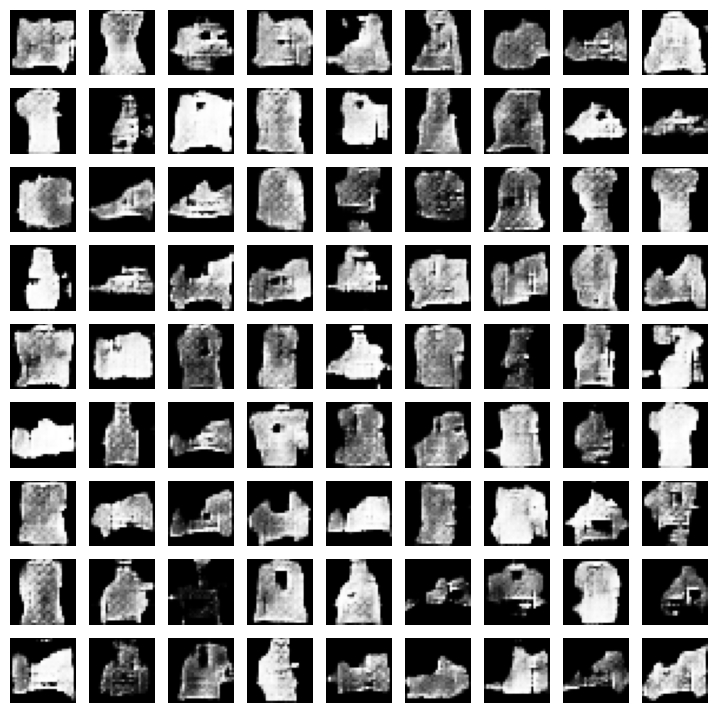

E:19, Loss G:1.6955, Loss D:0.3714, Acc G:%7.73, Acc D:%88.56
E:20, Loss G:1.6815, Loss D:0.3677, Acc G:%7.88, Acc D:%88.37


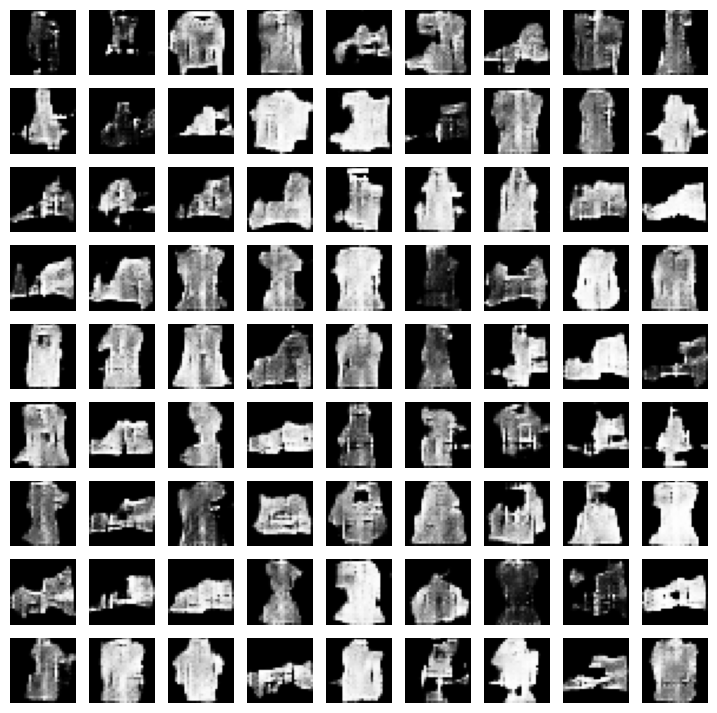

E:21, Loss G:1.6987, Loss D:0.3591, Acc G:%8.00, Acc D:%88.22
E:22, Loss G:1.6941, Loss D:0.3607, Acc G:%8.08, Acc D:%88.11


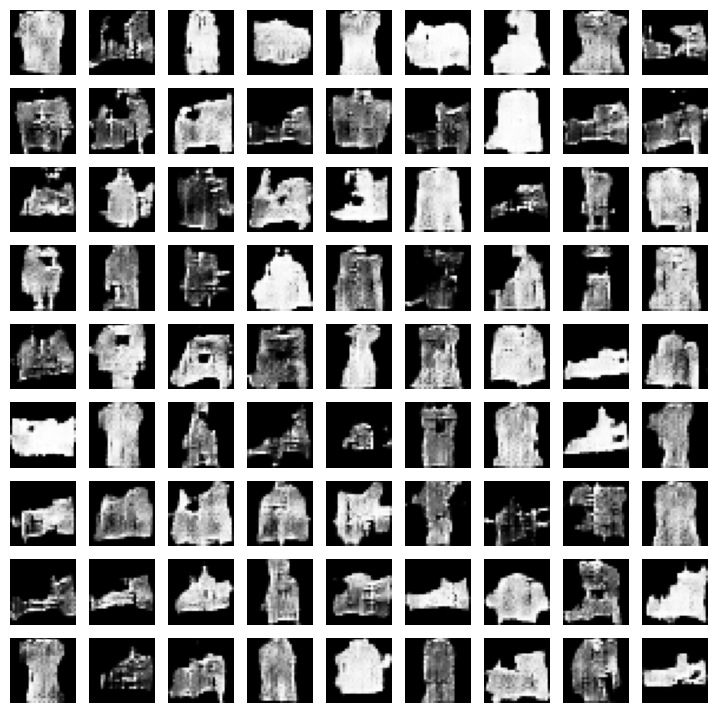

E:23, Loss G:1.6876, Loss D:0.3581, Acc G:%8.16, Acc D:%88.00
E:24, Loss G:1.6843, Loss D:0.3557, Acc G:%8.23, Acc D:%87.90


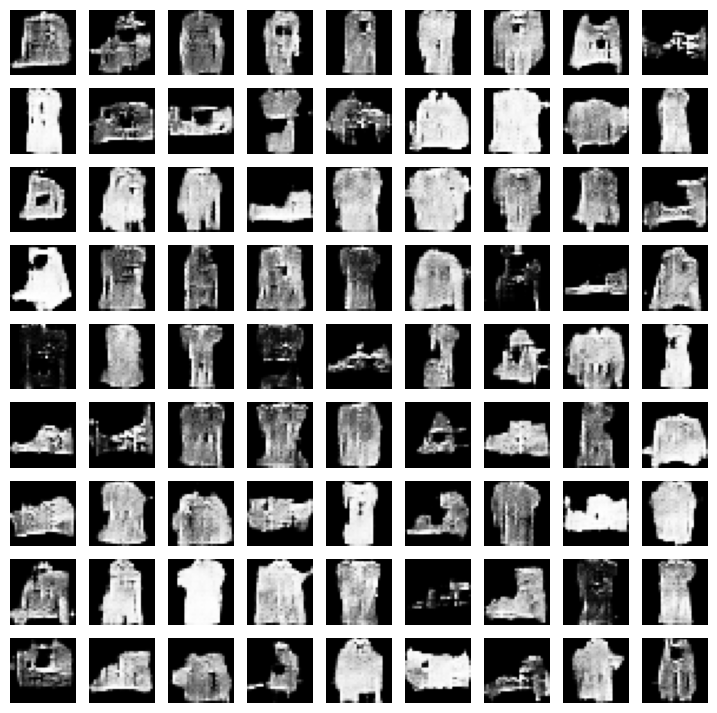

E:25, Loss G:1.6649, Loss D:0.3628, Acc G:%8.30, Acc D:%87.81
E:26, Loss G:1.6459, Loss D:0.3700, Acc G:%8.37, Acc D:%87.72


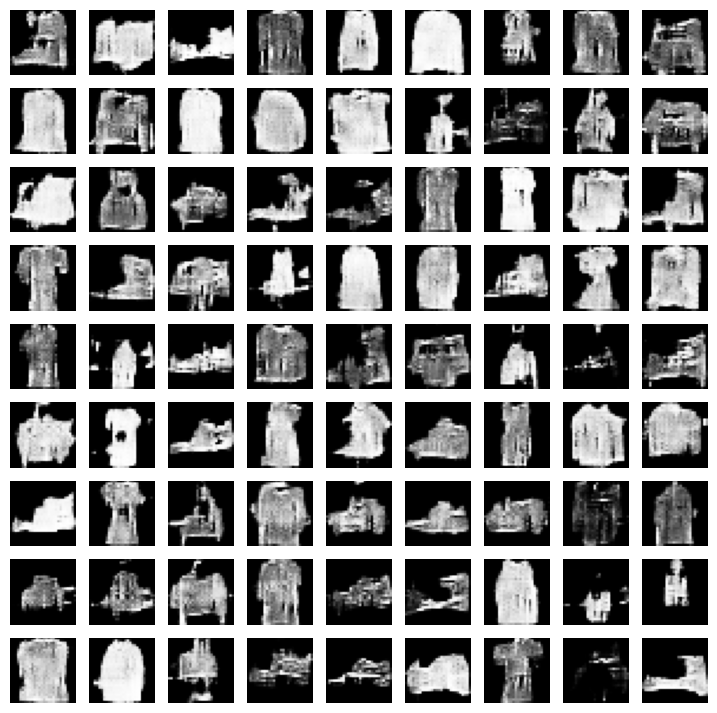

E:27, Loss G:1.6545, Loss D:0.3653, Acc G:%8.43, Acc D:%87.63
E:28, Loss G:1.6607, Loss D:0.3633, Acc G:%8.49, Acc D:%87.56


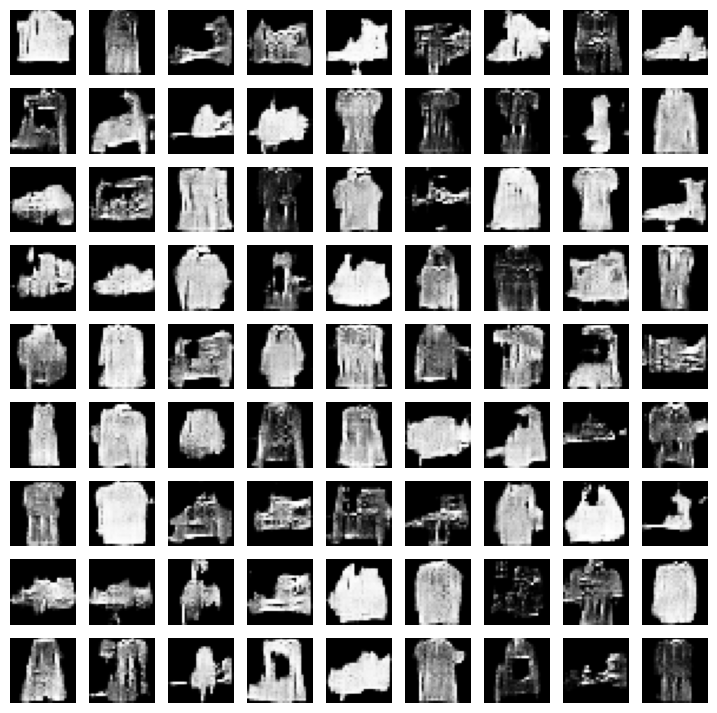

E:29, Loss G:1.6584, Loss D:0.3666, Acc G:%8.54, Acc D:%87.48


In [22]:
#treinando por 30 épocas
for epoch in range(30):

  #acumulando a loss para calcular a média ao fim da época
  dLossSum = 0
  gLossSum = 0
  dAccSum = 0
  gAccSum = 0
  cnt = 0

  #para cada batch no dataset
  for batch in dataset:

    #treinando o discriminador
    dLoss = trainDStep(batch)
    dLossSum += dLoss['discriminator_loss']
    dAccSum += dLoss['discriminator_accuracy']

    #treinando o gerador
    gLoss = trainGStep(batch)
    gLossSum += gLoss['generator_loss']
    gAccSum += gLoss['generator_accuracy']

    #aumentando o contador
    cnt += 1

  #dados por época
  print("E:{}, Loss G:{:0.4f}, Loss D:{:0.4f}, Acc G:%{:0.2f}, Acc D:%{:0.2f}".format(
      epoch,
      gLossSum/cnt,
      dLossSum/cnt,
      100 * gAccSum/cnt,
      100 * dAccSum/cnt
  ))
    
  #plotando a imagem quando a época for par
  if epoch % 2 == 0:
    plotImages(generator)

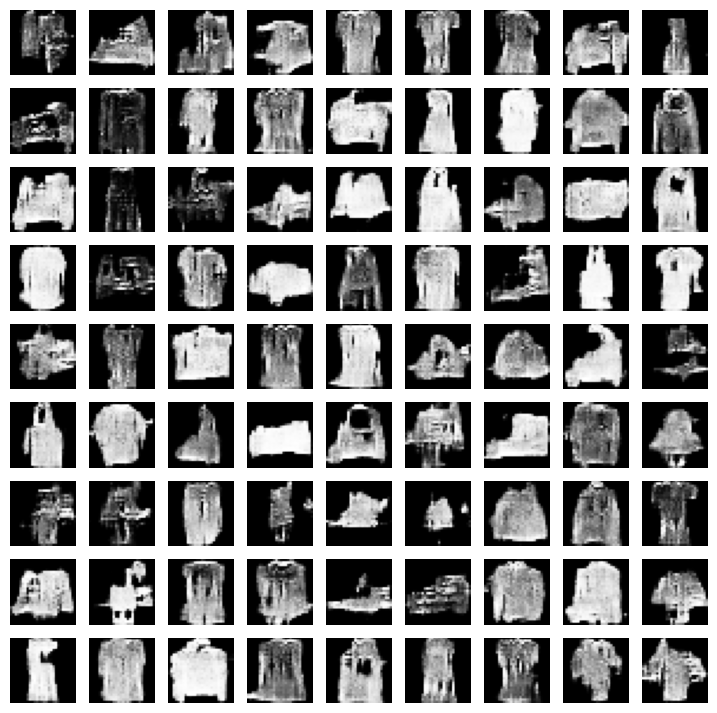

In [23]:
#gerando algumas imagens
images = generator(np.random.normal(size=(81, NOISE_DIM)))

#plotando
from matplotlib import pyplot as plt

plt.figure(figsize=(9, 9))

for i, image in enumerate(images):
    plt.subplot(9,9,i+1)
    plt.imshow(np.squeeze(image, -1), cmap="Greys_r")
    plt.axis('off')

plt.show();